<a href="https://colab.research.google.com/github/aggarwal-navya/customer-rfm-segmentation-analysis/blob/main/python/RFM_Demographic_Analysis.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [2]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plyt
import seaborn as sns
from google.colab import files

uploade= files.upload()

rfm_df = pd.read_csv('final_segmented_rfm.csv')
demo_df = pd.read_csv('hh_demographic.csv')

rfm_df.head()

Saving final_segmented_rfm.csv to final_segmented_rfm.csv
Saving hh_demographic.csv to hh_demographic.csv


,household_key,raw_recency,raw_frequency,raw_monetary,R_score,F_score,M_score,RFM_cell,customer_segment
0,1884,254,1,1.00,5,1,1,511,Potential Loyalist
1,1626,225,1,2.00,5,1,1,511,Potential Loyalist
2,1721,217,1,2.39,5,1,1,511,Potential Loyalist
3,2165,313,1,2.79,5,1,1,511,Potential Loyalist
4,423,253,1,3.00,5,1,1,511,Potential Loyalist


In [3]:
segment_profile = rfm_df.groupby('customer_segment').agg({
    'household_key': 'count',
    'raw_recency': 'mean',
    'raw_frequency': 'mean',
    'raw_monetary': ['mean', 'sum']
})
segment_profile.columns = ['total_customers', 'avg_recency', 'avg_frequency', 'avg_monetary', 'total_revenue']
segment_profile = segment_profile.reset_index()

total_business_revenue = rfm_df['raw_monetary'].sum()
segment_profile['revenue_percentage'] = round((segment_profile['total_revenue'] / total_business_revenue) * 100, 2)

segment_profile= segment_profile.round({'avg_recency':1, 'avg_frequency':1, 'avg_monetary':2, 'total_revenue':2})
segment_profile = segment_profile.sort_values(by='avg_monetary', ascending=False)

segment_profile

,customer_segment,total_customers,avg_recency,avg_frequency,avg_monetary,total_revenue,revenue_percentage
1,At Risk / Cant Loose,556,3.7,102.5,2939.73,1634487.52,51.08
2,Champions,81,28.8,69.0,1994.09,161521.29,5.05
4,Loyal Customer,456,16.3,49.7,1545.64,704812.20,22.03
0,About to sleep / Average Shopper,589,10.7,33.4,731.16,430654.11,13.46
3,Hibernating / Lost,110,4.3,14.0,337.55,37130.09,1.16
5,Potential Loyalist,705,79.3,10.4,327.73,231047.73,7.22


In [7]:
merged_df = pd.merge(rfm_df, demo_df, on='household_key', how='inner')
income_distribution = pd.crosstab(
    merged_df['customer_segment'],
    merged_df['INCOME_DESC'],
    normalize='index'
) * 100

income_distribution = income_distribution.round(1)
income_distribution

INCOME_DESC,100-124K,125-149K,15-24K,150-174K,175-199K,200-249K,25-34K,250K+,35-49K,50-74K,75-99K,Under 15K
customer_segment,,,,,,,,,,,,
About to sleep / Average Shopper,1.2,3.1,13.5,3.7,1.2,0.6,9.8,0.6,24.5,23.3,13.5,4.9
At Risk / Cant Loose,5.1,5.4,8.1,4.2,1.8,0.6,7.5,1.8,20.7,24.0,12.0,9.0
Champions,7.1,4.8,11.9,0.0,0.0,2.4,16.7,0.0,23.8,16.7,14.3,2.4
Hibernating / Lost,16.7,8.3,16.7,0.0,0.0,0.0,0.0,0.0,8.3,41.7,8.3,0.0
Loyal Customer,3.9,4.9,6.4,3.4,1.5,0.5,10.8,2.0,20.2,25.6,10.3,10.3
Potential Loyalist,4.3,4.3,10.6,6.4,0.0,0.0,14.9,0.0,23.4,21.3,12.8,2.1


In [6]:
print(demo_df.columns.tolist())

['AGE_DESC', 'MARITAL_STATUS_CODE', 'INCOME_DESC', 'HOMEOWNER_DESC', 'HH_COMP_DESC', 'HOUSEHOLD_SIZE_DESC', 'KID_CATEGORY_DESC', 'household_key']


In [8]:
revenue_by_income = pd.pivot_table(
    merged_df,
    values='raw_monetary',
    index='customer_segment',
    columns='INCOME_DESC',
    aggfunc='sum'
)

total_sales = merged_df['raw_monetary'].sum()
revenue_share_matrix = round((revenue_by_income / total_sales) * 100, 2)

revenue_share_matrix.fillna(0)

INCOME_DESC,100-124K,125-149K,15-24K,150-174K,175-199K,200-249K,25-34K,250K+,35-49K,50-74K,75-99K,Under 15K
customer_segment,,,,,,,,,,,,
About to sleep / Average Shopper,0.11,0.35,0.96,0.62,0.08,0.05,1.03,0.03,2.06,2.12,1.32,0.44
At Risk / Cant Loose,2.95,4.67,3.88,3.47,2.23,0.42,4.04,2.08,10.76,14.22,7.58,5.75
Champions,0.42,0.24,0.62,0.00,0.00,0.13,0.71,0.00,1.15,1.08,0.57,0.11
Hibernating / Lost,0.05,0.03,0.04,0.00,0.00,0.00,0.00,0.00,0.00,0.09,0.03,0.00
Loyal Customer,0.94,1.45,1.25,1.22,0.21,0.08,2.34,0.65,3.79,6.16,1.91,1.77
Potential Loyalist,0.09,0.15,0.12,0.14,0.00,0.00,0.26,0.00,0.35,0.31,0.28,0.01


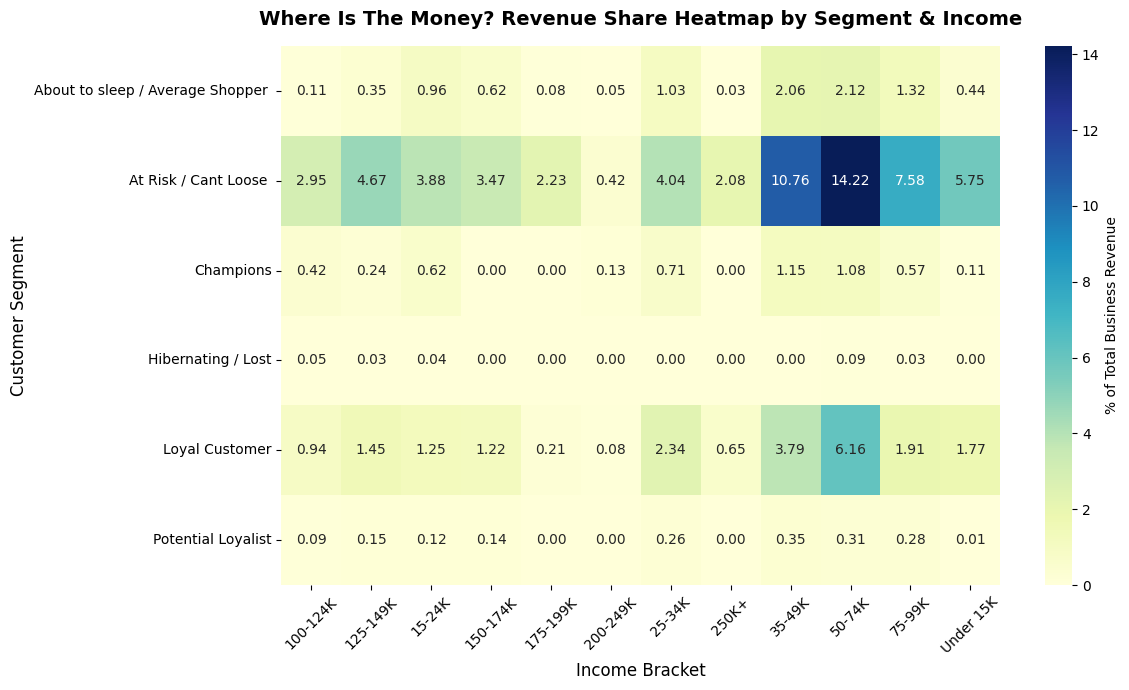

In [9]:
import seaborn as sns
import matplotlib.pyplot as plt

plt.figure(figsize=(12, 7))

sns.heatmap(
    revenue_share_matrix.fillna(0),
    annot=True,
    fmt=".2f",
    cmap="YlGnBu",
    cbar_kws={'label': '% of Total Business Revenue'}
)

plt.title('Where Is The Money? Revenue Share Heatmap by Segment & Income', fontsize=14, fontweight='bold', pad=15)
plt.ylabel('Customer Segment', fontsize=12)
plt.xlabel('Income Bracket', fontsize=12)
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

In [10]:
household_size_dist = pd.crosstab(
    merged_df['customer_segment'],
    merged_df['HOUSEHOLD_SIZE_DESC'],
    normalize='index'
) * 100
household_size_dist.round(1)

HOUSEHOLD_SIZE_DESC,1,2,3,4,5+
customer_segment,,,,,
About to sleep / Average Shopper,33.1,38.7,16.0,4.3,8.0
At Risk / Cant Loose,32.0,38.3,12.9,8.1,8.7
Champions,23.8,50.0,11.9,2.4,11.9
Hibernating / Lost,41.7,33.3,16.7,8.3,0.0
Loyal Customer,33.5,40.9,13.8,6.4,5.4
Potential Loyalist,23.4,40.4,10.6,8.5,17.0
